In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import sys
sys.path.insert(0, '../')
from ultility.metrics import rolling_std_vol
from ultility.models_garch import garch_forecast_fixed_params
from ultility.models_lstm_baseline import train_lstm_baseline, predict_lstm_baseline_rolling
from ultility.models_transformer import train_transformer
from ultility.lstmgarch import LSTMGARCH
from ultility.transformer_garch import TransformerGARCH
from ultility.eval_vol import save_and_plot
import torch
import warnings
warnings.filterwarnings('ignore')

Nu values: {'Stock returns': 4.0, 'VN30 Index': 4.0, 'VN Index': 4.0, 'DAX_40': 4.0, 'EuroNext_100': 4.0, 'IBEX_35': 4.0, 'KOSPI_index': np.float64(4.3570738396768895), 'SMI': 4.0, 'snp500': 4.0, 'Nikkei_225': np.float64(5.412576006188138)}
Using device: cpu | AMP: False
Training Stock returns...
Epoch [10/50], Train Loss: 0.949555
Epoch [20/50], Train Loss: 0.950452
Epoch [30/50], Train Loss: 0.948902
Epoch [40/50], Train Loss: 0.948314
Epoch [50/50], Train Loss: 0.947478
Training VN30 Index...
Epoch [10/50], Train Loss: 0.970030
Epoch [20/50], Train Loss: 0.968523
Epoch [30/50], Train Loss: 0.969242
Epoch [40/50], Train Loss: 0.969460
Epoch [50/50], Train Loss: 0.968187
Training VN Index...
Epoch [10/50], Train Loss: 0.962466
Epoch [20/50], Train Loss: 0.961844
Epoch [30/50], Train Loss: 0.961402
Epoch [40/50], Train Loss: 0.961713
Epoch [50/50], Train Loss: 0.957679
Training DAX_40...
Epoch [10/50], Train Loss: 0.800304
Epoch [20/50], Train Loss: 0.800448
Epoch [30/50], Train Loss: 

,Dataset,Model,status,elapsed_sec,error
18,DAX_40,GARCH,ok,0.022,
19,DAX_40,GJR-GARCH,ok,0.025,
20,DAX_40,LSTM,ok,25.365,
22,DAX_40,LSTMGARCH,ok,26.703,
21,DAX_40,Transformer,ok,200.959,
23,DAX_40,TransformerGARCH,ok,159.620,
24,EuroNext_100,GARCH,ok,0.026,
25,EuroNext_100,GJR-GARCH,ok,0.025,
26,EuroNext_100,LSTM,ok,17.736,
28,EuroNext_100,LSTMGARCH,ok,21.837,



Fallback count by model:


,Model,fallback_count
0,GARCH,0
1,GJR-GARCH,0
2,LSTM,0
3,LSTMGARCH,0
4,Transformer,0
5,TransformerGARCH,0


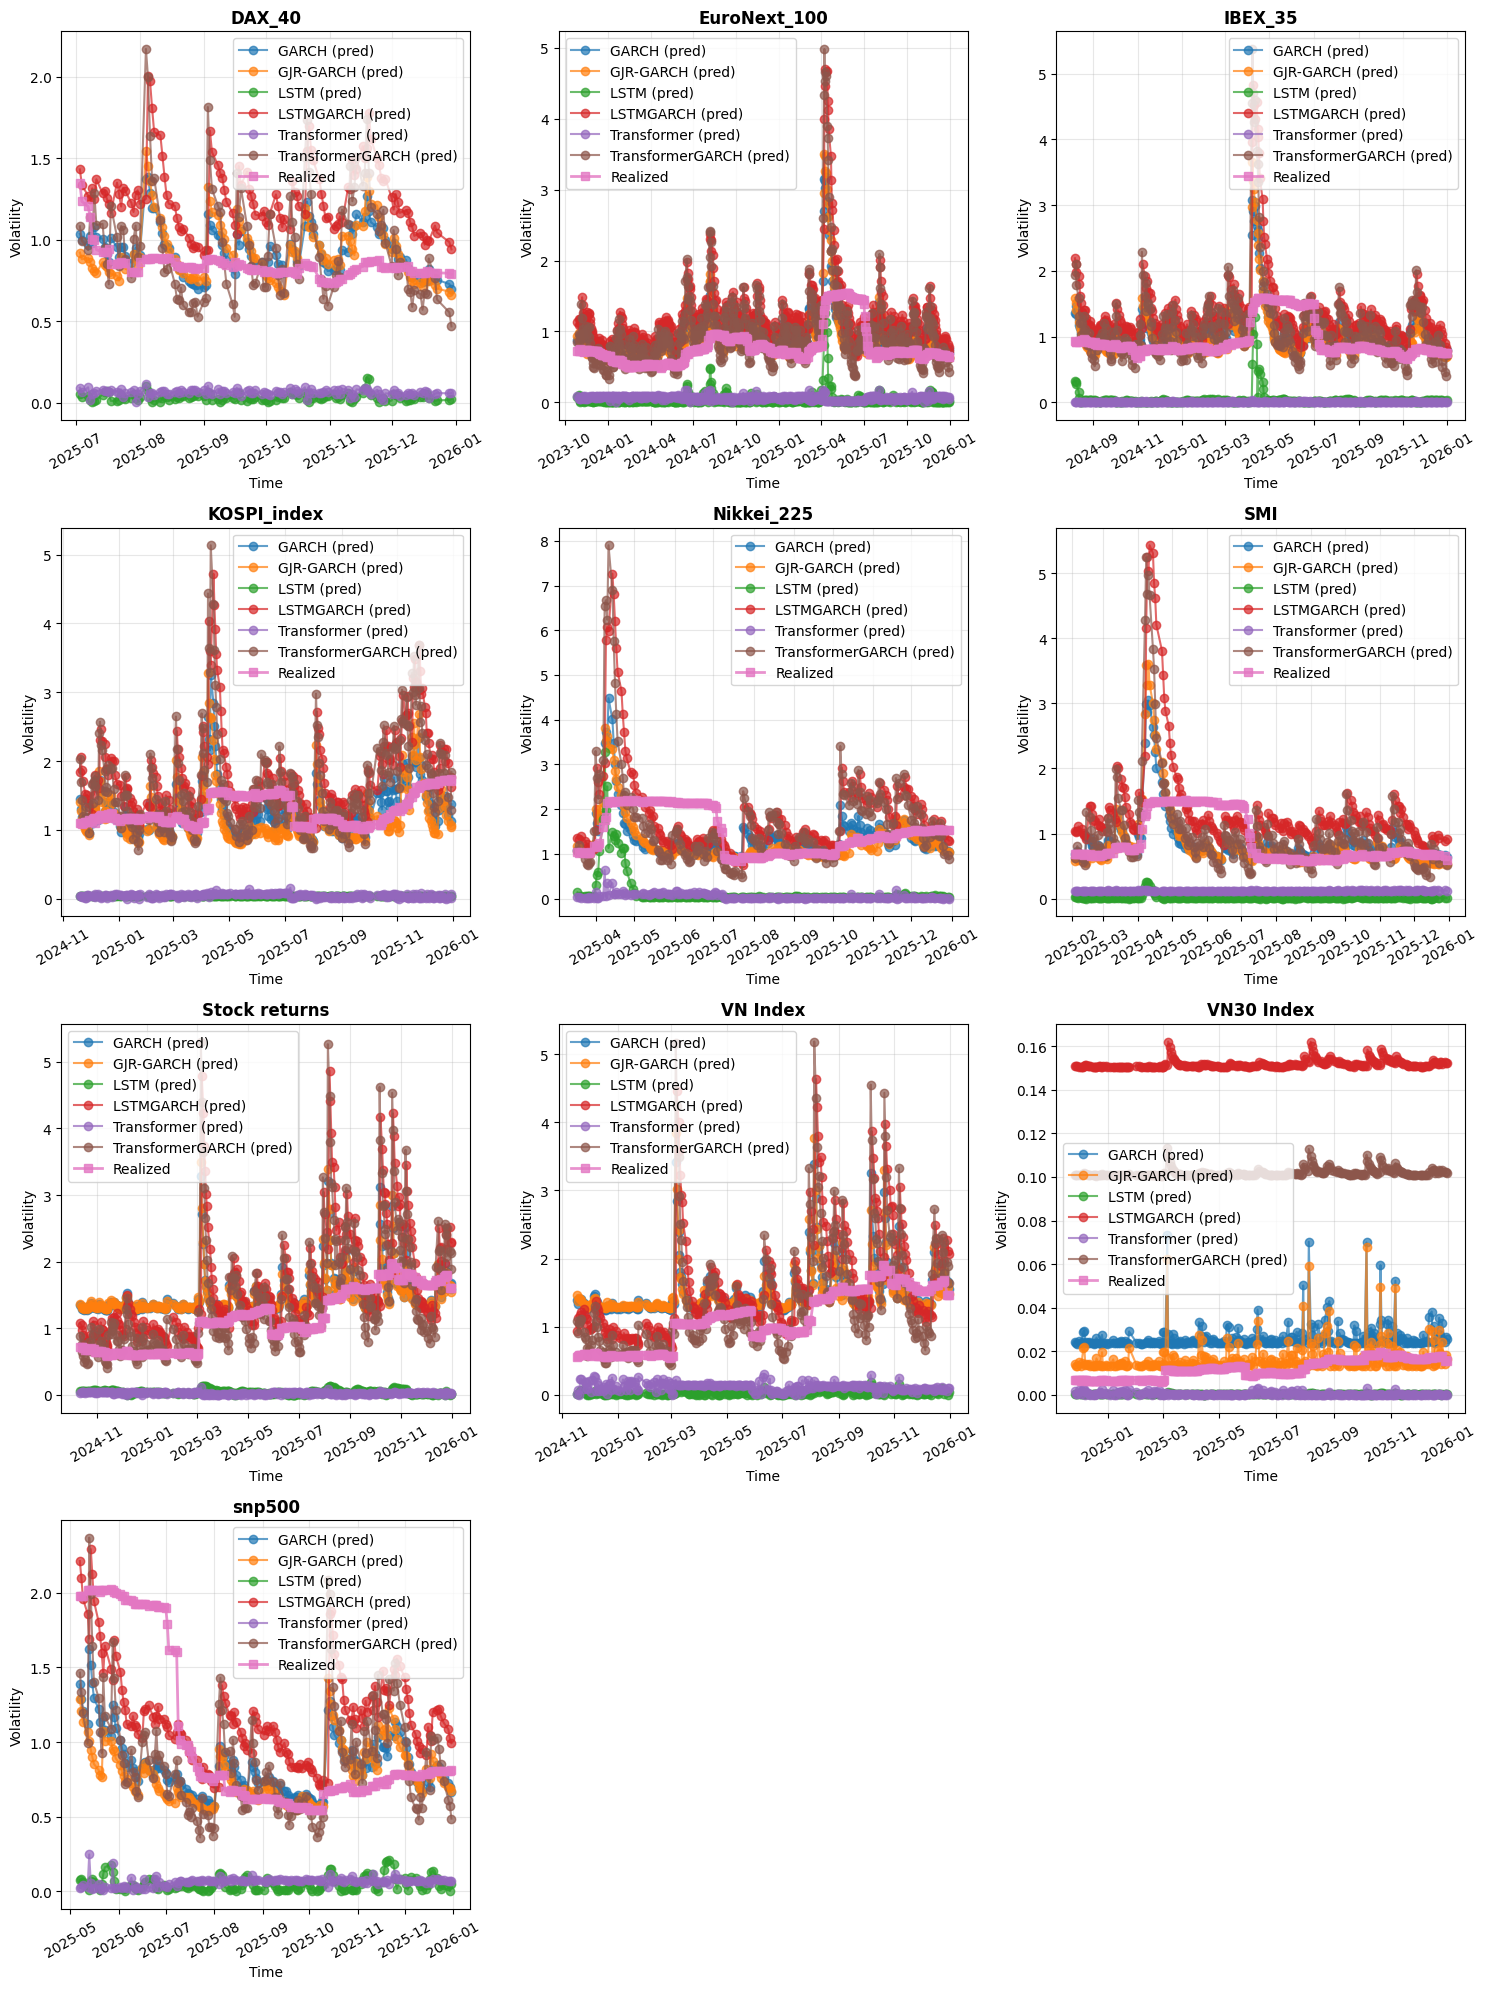

Predictions saved to ../output/predicts.csv
Results saved to ../output/models_results.csv
          Dataset             Model       MSE         QLIKE  \
0   Stock returns             GARCH  0.280502  1.436159e+00   
1   Stock returns         GJR-GARCH  0.285698  1.438107e+00   
2   Stock returns              LSTM  1.421758  4.898271e+05   
3   Stock returns       Transformer  1.464924  1.003123e+06   
4   Stock returns         LSTMGARCH  0.612945  1.396777e+00   
5   Stock returns  TransformerGARCH  0.567395  1.391190e+00   
6      VN30 Index             GARCH  0.000246 -7.051546e+00   
7      VN30 Index         GJR-GARCH  0.000075 -7.579812e+00   
8      VN30 Index              LSTM  0.000159  1.739180e+03   
9      VN30 Index       Transformer  0.000160  8.600028e+03   
10     VN30 Index         LSTMGARCH  0.019484 -3.762789e+00   
11     VN30 Index  TransformerGARCH  0.008053 -4.550612e+00   
12       VN Index             GARCH  0.311666  1.430687e+00   
13       VN Index         GJ

In [2]:
path = '../dataset/VN30_dataset_from_2019.csv'
df = pd.read_csv(path)
df['time'] = pd.to_datetime(df['time'], format='mixed', dayfirst=True, errors='coerce')
df_2020 = df[df['time'].dt.year >= 2020]

stocks_returns = (
    df_2020.sort_values('time').groupby('time')
    .apply(lambda x: np.average(x['return_1d'], weights=x['Market Capital (Bn VND)'] / x['Market Capital (Bn VND)'].sum()))
    .dropna()
)
stocks_returns = stocks_returns.sort_index().to_frame(name='stocks_return')
stocks_returns['stocks_return'] = stocks_returns['stocks_return'] * 100

datasets = {}
datasets['Stock returns'] = stocks_returns['stocks_return']

df_vn30 = pd.read_csv('../dataset/VN30_INDEX.csv')
df_vn30['time'] = pd.to_datetime(df_vn30['time'], format='mixed', dayfirst=True, errors='coerce')
df_vn30_2020 = df_vn30[df_vn30['time'].dt.year >= 2020].copy()
df_vn30_2020 = df_vn30_2020.dropna(subset=['time']).sort_values('time')
datasets['VN30 Index'] = (
    df_vn30_2020.set_index('time')['return_1_day'].astype(float).sort_index()
)

df_vn = pd.read_csv('../dataset/VN_INDEX.csv')
df_vn['time'] = pd.to_datetime(df_vn['time'], format='mixed', dayfirst=True, errors='coerce')
df_vn_2020 = df_vn[df_vn['time'].dt.year >= 2020].copy()
df_vn_2020 = df_vn_2020.dropna(subset=['time']).sort_values('time')
datasets['VN Index'] = (
    df_vn_2020.set_index('time')['return_1_day'].astype(float).sort_index() * 100
)

for file in ['DAX_40.csv', 'EuroNext_100.csv', 'IBEX_35.csv', 'KOSPI_index.csv', 'SMI.csv', 'snp500.csv', 'Nikkei_225.csv']:
    df_temp = pd.read_csv(f'../dataset/{file}')
    if 'Date' in df_temp.columns:
        df_temp.rename(columns={'Date': 'time'}, inplace=True)
    df_temp['time'] = pd.to_datetime(df_temp['time'], format='mixed', dayfirst=False, errors='coerce')
    df_temp = df_temp.dropna(subset=['time'])
    df_temp_2020 = df_temp[df_temp['time'].dt.year >= 2020].copy().sort_values('time')
    if 'close' in df_temp_2020.columns:
        close = pd.to_numeric(df_temp_2020['close'], errors='coerce')
        returns = np.log(close / close.shift(1)).replace([np.inf, -np.inf], np.nan).fillna(0.0) * 100
        datasets[file.replace('.csv', '')] = pd.Series(
            returns.values,
            index=df_temp_2020['time'].values,
        ).sort_index()

data = {
    'Dataset': ['Stock returns', 'VN30 Index', 'VN Index', 'DAX_40', 'EuroNext_100', 'IBEX_35', 'KOSPI_index', 'SMI', 'snp500', 'Nikkei_225'],
    'Train': [946, 886, 949, 1066, 769, 962, 979, 1055, 1054, 1021],
    'Val': [184, 279, 209, 276, 154, 159, 161, 168, 229, 189],
    'Test': [368, 334, 341, 186, 615, 421, 331, 287, 225, 255],
}
split_df = pd.DataFrame(data).set_index('Dataset')[['Train', 'Val', 'Test']]

nu_dict = {}
for ds, series in datasets.items():
    tr = int(split_df.loc[ds, 'Train'])
    train_data = series.iloc[:tr].values if hasattr(series, 'iloc') else series[:tr]
    if len(train_data) < 20:
        nu_dict[ds] = 8.0
        continue
    nu, loc, scale = stats.t.fit(train_data)
    nu_dict[ds] = max(nu, 4.0)
print('Nu values:', nu_dict)

import time

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    if hasattr(torch.backends, 'cuda') and hasattr(torch.backends.cuda, 'matmul'):
        torch.backends.cuda.matmul.allow_tf32 = True
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.allow_tf32 = True

GLOBAL_DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
USE_CUDA = GLOBAL_DEVICE.type == 'cuda'
print(f'Using device: {GLOBAL_DEVICE} | AMP: {USE_CUDA}')

train_cfg = {
    'seq_len': 60,
    'lstm_epochs': 50,
    'lstm_batch_size': 32,
    'lstm_lr': 3e-4,
    'transformer_epochs': 30,
    'transformer_batch_size': 64,
    'transformer_lr': 1e-3,
    'hybrid_epochs': 30,
    'hybrid_batch_size': 64,
    'hybrid_lr': 1e-3,
    'device': str(GLOBAL_DEVICE),
}
seq_len = train_cfg['seq_len']

def seq_x(x, s=60):
    x = np.asarray(x, dtype=np.float32)
    if len(x) <= s:
        return np.empty((0, s), np.float32)
    return np.stack([x[i:i+s] for i in range(len(x)-s)]).astype(np.float32)

def fit_lstmgarch_model(model, x, s=60, epochs=30, lr=1e-3, batch_size=64, device=None):
    device = torch.device(device) if device is not None else GLOBAL_DEVICE
    use_cuda = device.type == 'cuda'
    X = seq_x(x, s)
    model = model.to(device)
    if len(X) == 0:
        return model
    ds = torch.utils.data.TensorDataset(torch.tensor(X, dtype=torch.float32))
    dl = torch.utils.data.DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=use_cuda,
    )
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler('cuda', enabled=use_cuda)
    model.train()
    for _ in range(epochs):
        for (xb,) in dl:
            xb = xb.to(device, non_blocking=use_cuda)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type='cuda', enabled=use_cuda):
                loss, _ = model(xb)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(opt)
            scaler.update()
    return model

def pred_lstmgarch_model(model, train, test, s=60):
    device = next(model.parameters()).device
    hist = np.asarray(train, dtype=np.float32).tolist()
    out = []
    model.eval()
    with torch.no_grad():
        for x in np.asarray(test, dtype=np.float32):
            if len(hist) < s:
                out.append(np.nan)
                hist.append(float(x))
                continue
            xb = torch.tensor(np.asarray(hist[-s:], dtype=np.float32), device=device).unsqueeze(0)
            _, sigma2_seq = model(xb)
            sigma2 = torch.clamp(sigma2_seq[:, -1], min=1e-8)
            out.append(float(torch.sqrt(sigma2).cpu().numpy().reshape(-1)[0]))
            hist.append(float(x))
    return np.asarray(out, dtype=np.float32)

def fit_transformergarch_model(model, x, s=60, epochs=30, lr=1e-3, batch_size=64, device=None):
    device = torch.device(device) if device is not None else GLOBAL_DEVICE
    use_cuda = device.type == 'cuda'
    X = seq_x(x, s)
    model = model.to(device)
    if len(X) == 0:
        return model
    ds = torch.utils.data.TensorDataset(torch.tensor(X, dtype=torch.float32))
    dl = torch.utils.data.DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=use_cuda,
    )
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler('cuda', enabled=use_cuda)
    model.train()
    for _ in range(epochs):
        for (xb,) in dl:
            xb = xb.to(device, non_blocking=use_cuda)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type='cuda', enabled=use_cuda):
                loss = model.negative_log_likelihood(xb)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(opt)
            scaler.update()
    return model

def pred_transformergarch_model(model, train, test, s=60):
    device = next(model.parameters()).device
    hist = np.asarray(train, dtype=np.float32).tolist()
    out = []
    model.eval()
    with torch.no_grad():
        for x in np.asarray(test, dtype=np.float32):
            if len(hist) < s:
                out.append(np.nan)
                hist.append(float(x))
                continue
            xb = torch.tensor(np.asarray(hist[-s:], dtype=np.float32), device=device).unsqueeze(0)
            sigma2_next = model(xb).detach().cpu().numpy().reshape(-1)[0]
            out.append(float(np.sqrt(max(float(sigma2_next), 1e-8))))
            hist.append(float(x))
    return np.asarray(out, dtype=np.float32)

def run_lstm_model(train_set, test_set):
    model, scaler, _, _ = train_lstm_baseline(
        train_set,
        seq_len=seq_len,
        epochs=train_cfg['lstm_epochs'],
        batch_size=train_cfg['lstm_batch_size'],
        learning_rate=train_cfg['lstm_lr'],
        device=train_cfg['device'],
    )
    return predict_lstm_baseline_rolling(
        model,
        train_set,
        test_set,
        seq_len,
        scaler,
        device=train_cfg['device'],
    )

def run_transformer_model(train_set, test_set):
    return np.abs(
        train_transformer(
            train_set,
            test_set,
            seq_len=seq_len,
            epochs=train_cfg['transformer_epochs'],
            batch_size=train_cfg['transformer_batch_size'],
            learning_rate=train_cfg['transformer_lr'],
            device=train_cfg['device'],
        )
    )

predictions = {
    'GARCH': {},
    'GJR-GARCH': {},
    'LSTM': {},
    'Transformer': {},
    'LSTMGARCH': {},
    'TransformerGARCH': {},
}
run_logs = []

for ds, series in datasets.items():
    data_series = series.values if hasattr(series, 'values') else np.asarray(series)
    tr, va, te = map(int, split_df.loc[ds, ['Train', 'Val', 'Test']])
    train_set = np.asarray(data_series[:tr+va], dtype=np.float32)
    test_set = np.asarray(data_series[tr+va:tr+va+te], dtype=np.float32)

    print(f'Training {ds}...')

    def _run_or_fallback(model_name, runner):
        t0 = time.perf_counter()
        status = 'ok'
        err = ''
        try:
            pred = np.asarray(runner(), dtype=np.float32)
        except Exception as e:
            status = 'fallback'
            err = f'{type(e).__name__}: {e}'
            pred = np.asarray(rolling_std_vol(test_set, seq_len), dtype=np.float32)
            print(f'[WARN] {ds} - {model_name} fallback: {err}')

        elapsed = round(time.perf_counter() - t0, 3)
        run_logs.append({
            'Dataset': ds,
            'Model': model_name,
            'status': status,
            'elapsed_sec': elapsed,
            'error': err,
        })
        return np.abs(pred)

    predictions['GARCH'][ds] = _run_or_fallback(
        'GARCH',
        lambda: garch_forecast_fixed_params(train_set, test_set, 'GARCH'),
    )
    predictions['GJR-GARCH'][ds] = _run_or_fallback(
        'GJR-GARCH',
        lambda: garch_forecast_fixed_params(train_set, test_set, 'GJR-GARCH'),
    )
    predictions['LSTM'][ds] = _run_or_fallback(
        'LSTM',
        lambda: run_lstm_model(train_set, test_set),
    )
    predictions['Transformer'][ds] = _run_or_fallback(
        'Transformer',
        lambda: run_transformer_model(train_set, test_set),
    )
    predictions['LSTMGARCH'][ds] = _run_or_fallback(
        'LSTMGARCH',
        lambda: pred_lstmgarch_model(
            fit_lstmgarch_model(
                LSTMGARCH(),
                train_set,
                s=seq_len,
                epochs=train_cfg['hybrid_epochs'],
                lr=train_cfg['hybrid_lr'],
                batch_size=train_cfg['hybrid_batch_size'],
                device=train_cfg['device'],
            ),
            train_set,
            test_set,
            s=seq_len,
        ),
    )
    predictions['TransformerGARCH'][ds] = _run_or_fallback(
        'TransformerGARCH',
        lambda: pred_transformergarch_model(
            fit_transformergarch_model(
                TransformerGARCH(),
                train_set,
                s=seq_len,
                epochs=train_cfg['hybrid_epochs'],
                lr=train_cfg['hybrid_lr'],
                batch_size=train_cfg['hybrid_batch_size'],
                device=train_cfg['device'],
            ),
            train_set,
            test_set,
            s=seq_len,
        ),
    )

run_status_df = pd.DataFrame(run_logs).sort_values(['Dataset', 'Model'])
print('\nRun status summary:')
display(run_status_df[['Dataset', 'Model', 'status', 'elapsed_sec', 'error']])
print('\nFallback count by model:')
display(
    run_status_df.groupby('Model', as_index=False)['status']
    .apply(lambda s: int((s == 'fallback').sum()))
    .rename(columns={'status': 'fallback_count'})
)

preds_df, results_df = save_and_plot(datasets, split_df, predictions, nu_dict, seq_len=seq_len, output_dir='../output')
print('Predictions saved to ../output/predicts.csv')
print('Results saved to ../output/models_results.csv')
print(results_df)